## Data Pipeline

Pulls OHLCV bars from Binance.US, builds aligned 4h panels, and constructs a monthly-rebalanced universe of liquid USDT-quoted coins. Output is a single pickle consumed by every downstream signal notebook.

### Pull universe and apply exclusions

Get every TRADING USDT pair on Binance.US, then drop stablecoins, wrapped tokens, and Binance leveraged tokens.

In [3]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

client = bnb_client(tld='US')

STABLECOINS = {
    'USDC', 'BUSD', 'DAI', 'TUSD', 'FDUSD', 'USDE', 'PYUSD', 'USDP',
    'GUSD', 'UST', 'USTC', 'LUSD', 'SUSD', 'FRAX', 'USDS', 'USDD',
    'USDO', 'USD1', 'MUSD', 'CRVUSD',
}
WRAPPED = {
    'WBTC', 'WETH', 'STETH', 'CBETH', 'WBETH', 'SWETH', 'RETH',
    'WSTETH', 'TBTC', 'HBTC', 'RENBTC', 'CBBTC', 'WEETH', 'LBTC',
    'PAXG',  # tokenized gold; tracks gold not crypto
}

# Binance leveraged tokens follow the pattern <UNDERLYING><MOD><USDT>, e.g. BTCUPUSDT.
LEVERAGE_MODIFIERS = ('UP', 'DOWN', 'BULL', 'BEAR', '3L', '3S', '5L', '5S')


def is_binance_leveraged_token(symbol):
    if not symbol.endswith('USDT'):
        return False
    base = symbol[:-4]
    for mod in LEVERAGE_MODIFIERS:
        if base.endswith(mod) and len(base) - len(mod) >= 3:
            return True
    return False


def exclusion_reason(symbol):
    base = symbol[:-4]
    if base in STABLECOINS:
        return 'stablecoin'
    if base in WRAPPED:
        return 'wrapped'
    if is_binance_leveraged_token(symbol):
        return 'leveraged'
    return None


info = client.get_exchange_info()
all_symbols = sorted([s['symbol'] for s in info['symbols']
                      if s['symbol'].endswith('USDT') and s['status'] == 'TRADING'])

candidate_symbols = []
excluded = []
for sym in all_symbols:
    reason = exclusion_reason(sym)
    if reason:
        excluded.append((sym, reason))
    else:
        candidate_symbols.append(sym)

print(f"USDT pairs trading on Binance.US: {len(all_symbols)}")
print(f"Excluded: {len(excluded)} {dict(Counter(r for _, r in excluded))}")
print(f"Candidates: {len(candidate_symbols)}")

USDT pairs trading on Binance.US: 201
Excluded: 4 {'stablecoin': 3, 'wrapped': 1}
Candidates: 197


### Pull OHLCV for filtered universe

Fetch 4h klines from 2019-01-01 forward for each surviving symbol. Cache to disk so reruns resume instead of refetching from the exchange.

In [6]:
PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))

FREQ = '4h'
START_TS = '2019-01-01'


def get_binance_px(symbol, freq, start_ts=START_TS):
    data = client.get_historical_klines(symbol, freq, start_ts)
    if not data:
        return None
    columns = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
               'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume',
               'ignore']
    df = pd.DataFrame(data, columns=columns)
    # Binance returns POSIX milliseconds. Convert to naive UTC datetimes for downstream alignment.
    to_dt = lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc).replace(tzinfo=None)
    df['open_time'] = df['open_time'].map(to_dt)
    df['close_time'] = df['close_time'].map(to_dt)
    return df


raw_data = {}
for i, sym in enumerate(candidate_symbols):
    try:
        df = get_binance_px(sym, FREQ)
        if df is None or len(df) == 0:
            print(f"  [{i+1}/{len(candidate_symbols)}] {sym} no data, skipped")
            continue
        raw_data[sym] = df
    except Exception as e:
        print(f"  ERROR on {sym}: {type(e).__name__}: {e}")
        time.sleep(5)
    time.sleep(0.15)

print(f"Pulled {len(raw_data)} coins")

# Build close-price panel and returns from the in-memory pull.
px = pd.DataFrame({sym: df.set_index('open_time')['close'].astype(float)
                   for sym, df in raw_data.items()})
px = px.reindex(pd.date_range(px.index.min(), px.index.max(), freq=FREQ))
ret = px.pct_change(fill_method=None)

print(f"px shape: {px.shape}")
print(f"Time range: {px.index.min()} to {px.index.max()}")

Pulled 197 coins
px shape: (14569, 197)
Time range: 2019-09-23 08:00:00 to 2026-05-17 08:00:00


### Build aligned panels

Extract per-coin price, volume, and trade-count series and reindex to a common 4h grid.

In [7]:
def extract_panel_num_col(raw_data, column):
    series_by_coin = {sym: df.set_index('open_time')[column].astype(float)
                      for sym, df in raw_data.items()}
    panel = pd.DataFrame(series_by_coin)
    return panel.reindex(pd.date_range(panel.index.min(), panel.index.max(), freq=FREQ))


dvol = extract_panel_num_col(raw_data, 'quote_volume')
taker_buy_dvol = extract_panel_num_col(raw_data, 'taker_quote_volume')
num_trades = extract_panel_num_col(raw_data, 'num_trades')
high_px = extract_panel_num_col(raw_data, 'high')
low_px = extract_panel_num_col(raw_data, 'low')
close_px = extract_panel_num_col(raw_data, 'close')

dvol_daily = dvol.resample('1D').sum()

print(f"4h panels: {px.shape[0]} bars x {px.shape[1]} coins")
print(f"BTC daily dollar volume (last 5 days):")
print(dvol_daily['BTCUSDT'].dropna().tail().round(0))

4h panels: 14569 bars x 197 coins
BTC daily dollar volume (last 5 days):
2026-05-13    8354206.0
2026-05-14    4015533.0
2026-05-15    3009707.0
2026-05-16    3382842.0
2026-05-17     152104.0
Freq: D, Name: BTCUSDT, dtype: float64


### Universe membership matrix

Monthly rebalanced. A coin is in the universe on date t if it has at least 180 days of history, passes a $5K/day absolute volume floor, and ranks in the top 50 by trailing 30d average daily dollar volume on entry, or stays top 70 once already in.

NOTE: Binance.US is less liquid then binance global. The idea here is that slippage costs are higher on binance.us but in the real world we'd likely trade in global markets.

/var/folders/jd/_635316n0v32p9bp2q1n5bbm5n8rcm/T/ipykernel_4225/3852046133.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries = u_monthly & ~u_monthly.shift(1).fillna(False).infer_objects(copy=False)
/var/folders/jd/_635316n0v32p9bp2q1n5bbm5n8rcm/T/ipykernel_4225/3852046133.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits = ~u_monthly & u_monthly.shift(1).fillna(False).infer_objects(copy=False)


Universe shape: (14569, 197) (entry rank top 50, exit rank top 70)
Mean monthly turnover: 9.0%
Universe size: min 0, max 63, current 47
Universe size SD post-2022: 10.2


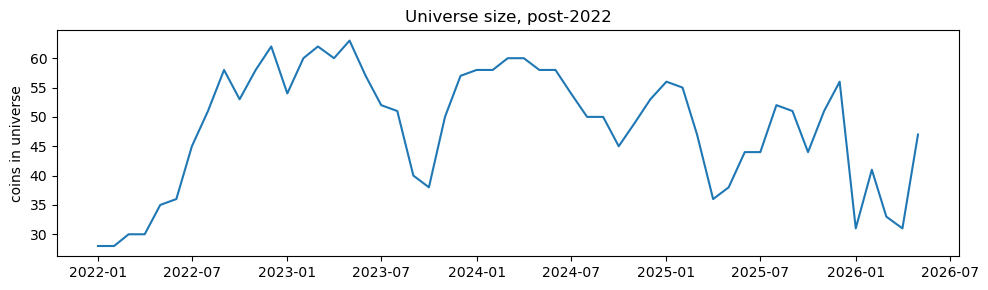

In [8]:
MIN_HISTORY_DAYS = 180
MIN_DVOL_ABSOLUTE = 5_000  # $/day floor
ENTRY_RANK = 50
EXIT_RANK = 70

# Trailing 30d average daily dollar volume per coin.
dvol_30d_avg = dvol_daily.rolling(30).mean()

# History counter at daily resolution.
daily_close = px.resample('1D').last()
history_days = daily_close.notna().cumsum()
history_aligned = history_days.reindex(dvol_30d_avg.index, method='ffill')

history_ok = history_aligned >= MIN_HISTORY_DAYS
dvol_ok = dvol_30d_avg >= MIN_DVOL_ABSOLUTE

# Rank only among coins passing both gates so ineligibles do not crowd the rank.
vol_eligible = dvol_30d_avg.where(history_ok & dvol_ok)
vol_rank = vol_eligible.rank(axis=1, ascending=False, method='min')

# Resample to monthly evaluation dates.
rank_monthly = vol_rank.resample('MS').first()
dvol_ok_monthly = dvol_ok.resample('MS').first().fillna(False).infer_objects(copy=False)

# enter at rank <= ENTRY_RANK stay until rank > EXIT_RANK.
universe_monthly = pd.DataFrame(False, index=rank_monthly.index, columns=rank_monthly.columns)
prev_in = pd.Series(False, index=rank_monthly.columns)
for date in rank_monthly.index:
    ranks = rank_monthly.loc[date]
    dvol_ok_today = dvol_ok_monthly.loc[date]
    stays = prev_in & (ranks <= EXIT_RANK) & dvol_ok_today
    enters = (~prev_in) & (ranks <= ENTRY_RANK) & dvol_ok_today
    this_month = (stays | enters).fillna(False).infer_objects(copy=False)
    universe_monthly.loc[date] = this_month
    prev_in = this_month

universe_daily = universe_monthly.reindex(dvol_30d_avg.index, method='ffill').fillna(False).infer_objects(copy=False)
universe = universe_daily.reindex(px.index, method='ffill').fillna(False).infer_objects(copy=False)

u_monthly = universe.resample('MS').first()
entries = u_monthly & ~u_monthly.shift(1).fillna(False).infer_objects(copy=False)
exits = ~u_monthly & u_monthly.shift(1).fillna(False).infer_objects(copy=False)
churn = pd.DataFrame({
    'universe_size': u_monthly.sum(axis=1),
    'entries': entries.sum(axis=1),
    'exits': exits.sum(axis=1),
})
churn['turnover_pct'] = (churn['entries'] + churn['exits']) / (2 * churn['universe_size'].replace(0, np.nan)) * 100

print(f"Universe shape: {universe.shape} (entry rank top {ENTRY_RANK}, exit rank top {EXIT_RANK})")
print(f"Mean monthly turnover: {churn['turnover_pct'].mean():.1f}%")
print(f"Universe size: min {churn['universe_size'].min()}, max {churn['universe_size'].max()}, current {universe.iloc[-1].sum():.0f}")
print(f"Universe size SD post-2022: {churn['universe_size'].loc['2022-01-01':].std():.1f}")

# Pre-2022 size is dominated by the 180-day-history ramp-up so we're only plotting post 2022.
plt.figure(figsize=(10, 3))
plt.plot(churn['universe_size'].loc['2022-01-01':])
plt.title('Universe size, post-2022')
plt.ylabel('coins in universe')
plt.tight_layout()
plt.show()

### Save panels

In [9]:
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')

panels = {
    'px': px,
    'ret': ret,
    'dvol': dvol,
    'taker_buy_dvol': taker_buy_dvol,
    'num_trades': num_trades,
    'high_px': high_px,
    'low_px': low_px,
    'close_px': close_px,
    'universe_daily': universe_daily,
    'universe_monthly': universe_monthly,
    'universe': universe,
    'candidate_symbols': list(raw_data.keys()),
}
with open(PANEL_DATA_PATH, 'wb') as f:
    pickle.dump(panels, f)

print(f"Saved {len(panels)} panels to {PANEL_DATA_PATH}")

Saved 12 panels to /Users/muditlam/data/binance_ohlcv_panel_4h.pkl
